# 🎓 Student Performance Prediction using Deep Learning

## Introduction
This project aims to predict students' final grades (G3) using machine learning and deep learning techniques.

The system analyzes behavioral, academic, and lifestyle features to identify patterns affecting student performance.

A deep learning model is implemented using TensorFlow and Keras.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Dataset
We use the Student Performance dataset which contains student information such as study habits, family background, and grades.

In [2]:
data = pd.read_csv("student-mat.csv", sep=";")
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Data Exploration
Understanding dataset structure and statistics

In [3]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## Correlation Analysis

A correlation heatmap was used to analyze relationships between features.

G1 and G2 show strong positive correlation with G3, making them important predictors.  
Failures and absences show negative impact on performance.

These insights were used to select relevant features for the model.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

selected = data[[
    "G3","G2","G1","studytime","failures","absences",
    "goout","Dalc","Walc"
]]

sns.heatmap(selected.corr(), annot=True, cmap="coolwarm")

plt.title("Key Feature Correlation")
plt.show()

## Feature Selection
The selected features were chosen based on their relevance to student performance, such as academic history (G1, G2), study habits, and lifestyle factors.

In [4]:
features = [
"age","Medu","Fedu","traveltime","studytime","failures",
"famrel","freetime","goout","Dalc","Walc","health",
"absences","G1","G2"
]

X = data[features]
y = data["G3"]

## Train-Test Split
Splitting dataset into training and testing sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.linear_model import LinearRegression

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MSE:", lr_mse)
print("R2:", lr_r2)

Linear Regression Results
MSE: 4.503769153719584
R2: 0.7803580213768331


## Data Scaling
Scaling is important for deep learning models

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Deep Learning Model
We implement a multi-layer neural network using TensorFlow and Keras.

In [8]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

## Model Compilation

In [9]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

## Model Training

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 119.8232 - mae: 9.9768 - val_loss: 107.3218 - val_mae: 9.6075
Epoch 2/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 99.5789 - mae: 9.1369 - val_loss: 87.3327 - val_mae: 8.6404
Epoch 3/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 79.1544 - mae: 8.1401 - val_loss: 65.1662 - val_mae: 7.3979
Epoch 4/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 56.6257 - mae: 6.8483 - val_loss: 41.7042 - val_mae: 5.8507
Epoch 5/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 35.0332 - mae: 5.3140 - val_loss: 22.4541 - val_mae: 4.2156
Epoch 6/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 19.7178 - mae: 3.8380 - val_loss: 13.0041 - val_mae: 2.9706
Epoch 7/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 12.9034 - mae: 2.8337 - val_loss: 10.6304 - val_mae: 2.4346
Epoch 8/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 10.7341 - mae: 2.5117 - val_loss: 10.1959 - val_mae: 2.3663
Epoch 9/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/

In [11]:
# Save model
model.save("model.keras")

# Save scaler
import joblib
joblib.dump(scaler, "scaler.pkl")

print("✅ Model & Scaler saved!")

✅ Model & Scaler saved!


## Model Evaluation

In [12]:
y_pred = model.predict(X_test)

print("Deep Learning Results")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

print("\n=== Model Comparison ===")
print("Linear Regression R2:", lr_r2)
print("Deep Learning R2:", r2_score(y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Deep Learning Results
MSE: 6.308056354522705
R2: 0.6923657059669495

=== Model Comparison ===
Linear Regression R2: 0.7803580213768331
Deep Learning R2: 0.6923657059669495


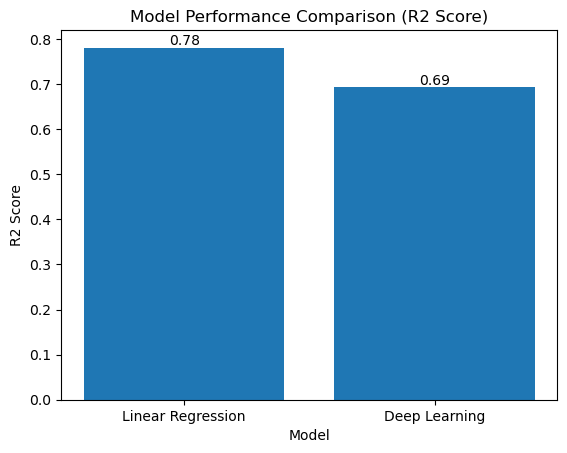

In [13]:
import matplotlib.pyplot as plt

# เก็บค่า R2
models = ["Linear Regression", "Deep Learning"]
scores = [lr_r2, r2_score(y_test, y_pred)]

# สร้างกราฟ
plt.figure()
plt.bar(models, scores)

plt.title("Model Performance Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")

# แสดงค่าบนกราฟ
for i, v in enumerate(scores):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.show()

## Training Visualization

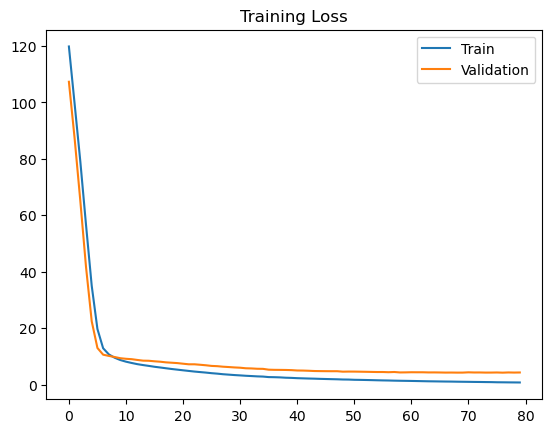

In [14]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train","Validation"])
plt.title("Training Loss")
plt.show()

## Conclusion

The deep learning model successfully predicts student performance.

The system can be used as an early warning tool to identify students at risk.

In [ ]:
# print("\n=== Test New Student ===")

age = float(input("Age (15-22): "))
Medu = float(input("Mother Education (0-4): "))
Fedu = float(input("Father Education (0-4): "))
traveltime = float(input("Travel Time (1-4): "))
studytime = float(input("Study Time (1-4): "))
failures = float(input("Past Failures (0-3): "))
famrel = float(input("Family Relationship (1-5): "))
freetime = float(input("Free Time (1-5): "))
goout = float(input("Going Out (1-5): "))
Dalc = float(input("Workday Alcohol (1-5): "))
Walc = float(input("Weekend Alcohol (1-5): "))
health = float(input("Health (1-5): "))
absences = float(input("Absences (0-30): "))
G1 = float(input("First Grade (0-20): "))
G2 = float(input("Second Grade (0-20): "))

In [ ]:
new_data = pd.DataFrame([[
    age, Medu, Fedu, traveltime, studytime, failures,
    famrel, freetime, goout, Dalc, Walc, health,
    absences, G1, G2
]], columns=features)

new_data = scaler.transform(new_data)

prediction = model.predict(new_data)[0][0]


prediction = max(0, min(20, prediction))

print("Predicted Final Grade:", prediction)

if prediction < 10:
    print("🔴 High Risk (Student may fail)")
elif prediction < 14:
    print("🟠 Medium Risk (Needs improvement)")
else:
    print("🟢 Low Risk (Performing well)")